# Responsible & Sovereign AI: Fairness in Healthcare

This notebook explores a practical question:

> **Can we improve fairness without sacrificing too much predictive performance?**

Using an African healthcare dataset, I compare three approaches: a baseline Logistic Regression, Fairlearn post-processing, and a fairness-aware neural network.

**Focus:** predictive quality, group disparities, and the trade-offs introduced by mitigation.


### Quick results

| Model | Accuracy | DPD | EOD |
|---|---:|---:|---:|
| Baseline Logistic Regression | 0.848 | 0.153 | 0.167 |
| Fairlearn ThresholdOptimizer | **0.863** | 0.023 | **0.016** |
| Standard Neural Network | 0.848 | 0.157 | 0.171 |
| Fairness-aware Neural Network | 0.822 | **0.002** | 0.019 |

The two mitigation strategies both reduce disparity, but they do so with very different performance trade-offs.


## Setup

Install Fairlearn before running the notebook.


In [1]:
!pip install -q fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.9 MB/s eta 0:00:00


## Imports and reproducibility

Libraries, plotting settings, and random seeds.


In [2]:
# ============================================================
# Import Libraries and Set Random Seeds
# ============================================================

import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate
)

from fairlearn.postprocessing import ThresholdOptimizer

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the healthcare data

The dataset contains **16,000 patient records** with demographic, access-to-care, lifestyle, and clinical variables.


In [9]:
from google.colab import drive

drive.mount("/content/drive")
dataset_path = "/content/Health_Equity_Dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Mounted at /content/drive
Dataset loaded successfully.
Dataset shape: (16000, 16)


,Patient_ID,Age,Sex,Residence,Income_Group,Health_Insurance,Distance_to_Clinic_km,Wait_Time_Minutes,BMI,Smoker,Physical_Activity_Days,Family_History,Systolic_BP,Glucose,Cholesterol,Outcome
0,AHEV4-00001,42,Male,Rural,Middle,1,23.8,48,28.1,1,4,0,124,95.2,154.8,0
1,AHEV4-00002,81,Female,Urban,Middle,1,6.2,50,18.8,0,1,0,129,99.9,197.4,1
2,AHEV4-00003,39,Male,Urban,Low,0,6.7,63,24.5,0,3,1,119,98.9,151.3,0
3,AHEV4-00004,47,Male,Urban,Middle,1,1.9,58,28.7,0,2,0,129,109.4,186.6,0
4,AHEV4-00005,35,Female,Urban,Middle,1,14.3,43,26.2,0,6,1,113,84.8,140.4,0


## 2. Explore the data

I first check data quality, class balance, group representation, and relationships between features and the target.


In [10]:
# ============================================================
# Exploratory Data Analysis
# ============================================================

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

print("FIRST FIVE ROWS")
display(df.head())

display(df.dtypes.to_frame(name="Data Type"))


Number of Rows: 16000
Number of Columns: 16
FIRST FIVE ROWS


,Patient_ID,Age,Sex,Residence,Income_Group,Health_Insurance,Distance_to_Clinic_km,Wait_Time_Minutes,BMI,Smoker,Physical_Activity_Days,Family_History,Systolic_BP,Glucose,Cholesterol,Outcome
0,AHEV4-00001,42,Male,Rural,Middle,1,23.8,48,28.1,1,4,0,124,95.2,154.8,0
1,AHEV4-00002,81,Female,Urban,Middle,1,6.2,50,18.8,0,1,0,129,99.9,197.4,1
2,AHEV4-00003,39,Male,Urban,Low,0,6.7,63,24.5,0,3,1,119,98.9,151.3,0
3,AHEV4-00004,47,Male,Urban,Middle,1,1.9,58,28.7,0,2,0,129,109.4,186.6,0
4,AHEV4-00005,35,Female,Urban,Middle,1,14.3,43,26.2,0,6,1,113,84.8,140.4,0


,Data Type
Patient_ID,object
Age,int64
Sex,object
Residence,object
Income_Group,object
Health_Insurance,int64
Distance_to_Clinic_km,float64
Wait_Time_Minutes,int64
BMI,float64
Smoker,int64


In [11]:
print("=" * 70)
print("MISSING VALUES")
print("\n" + "=" * 70)
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(
    missing_values[
        missing_values["Missing Count"] > 0
    ]
)

if df.isnull().sum().sum() == 0:
    print("There are no missing values.")
print("DUPLICATED ROWS")
print("Number of duplicated rows:", df.duplicated().sum())

print("\n" + "=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)
display(df.describe().T)

print("\n" + "=" * 70)
print("CATEGORICAL SUMMARY")
print("=" * 70)
display(
    df.select_dtypes(
        include=["object", "category"]
    ).describe().T
)

MISSING VALUES



,Missing Count,Missing Percentage


There are no missing values.
DUPLICATED ROWS
Number of duplicated rows: 0

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Age,16000.0,49.505688,14.796749,18.0,39.0,49.0,60.0,90.0
Health_Insurance,16000.0,0.468875,0.499046,0.0,0.0,0.0,1.0,1.0
Distance_to_Clinic_km,16000.0,8.612200,8.510796,0.5,3.0,5.7,11.2,81.4
Wait_Time_Minutes,16000.0,54.651750,18.739645,5.0,41.0,54.0,68.0,127.0
BMI,16000.0,26.013775,4.231775,12.3,23.2,26.0,28.9,43.3
Smoker,16000.0,0.203187,0.402383,0.0,0.0,0.0,0.0,1.0
Physical_Activity_Days,16000.0,3.177375,1.723216,0.0,2.0,3.0,4.0,7.0
Family_History,16000.0,0.322062,0.467281,0.0,0.0,0.0,1.0,1.0
Systolic_BP,16000.0,118.068875,16.242540,62.0,107.0,118.0,129.0,181.0
Glucose,16000.0,92.222431,16.454833,36.4,80.8,92.3,103.3,157.9



CATEGORICAL SUMMARY


,count,unique,top,freq
Patient_ID,16000,16000,AHEV4-15984,1
Sex,16000,2,Female,8326
Residence,16000,2,Urban,8982
Income_Group,16000,3,Low,7240



Outcome distribution:


,Outcome,Count
0,0,9358
1,1,6642



Outcome proportions:


,Outcome,Proportion
0,0,0.584875
1,1,0.415125


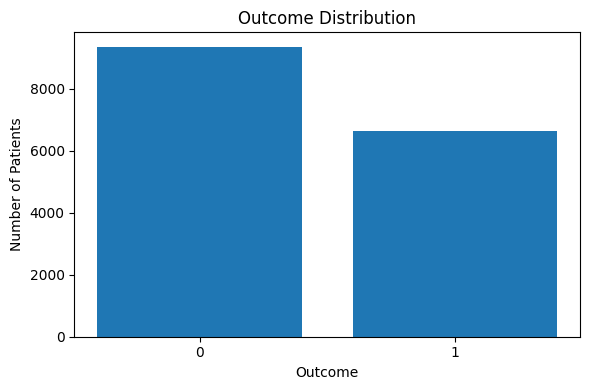

In [12]:
# ------------------------------------------------------------
# Outcome distribution
# ------------------------------------------------------------
print("\nOutcome distribution:")
display(
    df["Outcome"]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Count")
)

print("\nOutcome proportions:")
display(
    df["Outcome"]
    .value_counts(normalize=True)
    .rename_axis("Outcome")
    .reset_index(name="Proportion")
)

plt.figure(figsize=(6, 4))

outcome_counts = (
    df["Outcome"]
    .value_counts()
    .sort_index()
)

plt.bar(
    outcome_counts.index.astype(str),
    outcome_counts.values
)

plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


Sex distribution:


,Sex,Count
0,Female,8326
1,Male,7674


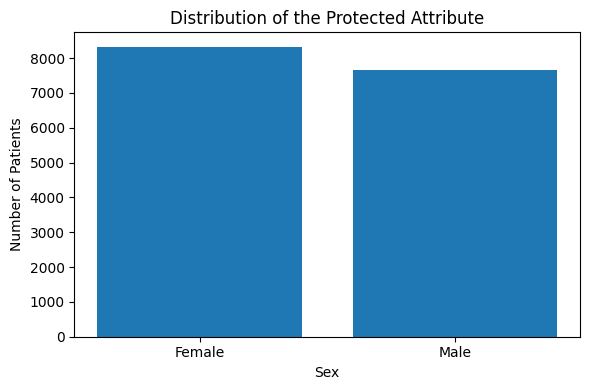

In [13]:
# ------------------------------------------------------------
# Protected attribute distribution
# ------------------------------------------------------------
print("\nSex distribution:")
display(
    df["Sex"]
    .value_counts()
    .rename_axis("Sex")
    .reset_index(name="Count")
)

plt.figure(figsize=(6, 4))

sex_counts = df["Sex"].value_counts()

plt.bar(
    sex_counts.index,
    sex_counts.values
)

plt.title("Distribution of the Protected Attribute")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


Positive outcome rate by Sex:


,Positive Outcome Rate
Sex,
Female,0.408720
Male,0.422075


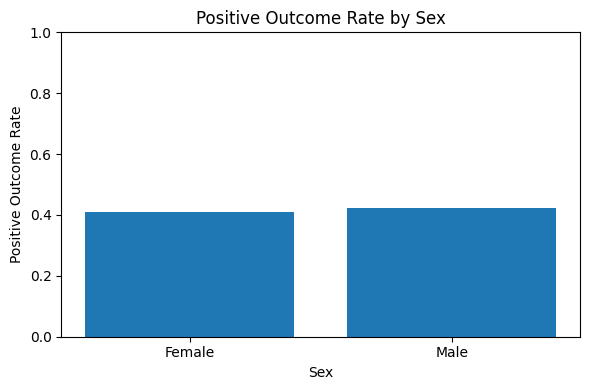

In [14]:
# ------------------------------------------------------------
# Outcome rate by protected group
# ------------------------------------------------------------
outcome_by_sex = (
    df.groupby("Sex")["Outcome"]
    .mean()
    .sort_values()
)

print("\nPositive outcome rate by Sex:")
display(
    outcome_by_sex
    .rename("Positive Outcome Rate")
    .to_frame()
)

plt.figure(figsize=(6, 4))

plt.bar(
    outcome_by_sex.index,
    outcome_by_sex.values
)

plt.title("Positive Outcome Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Positive Outcome Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

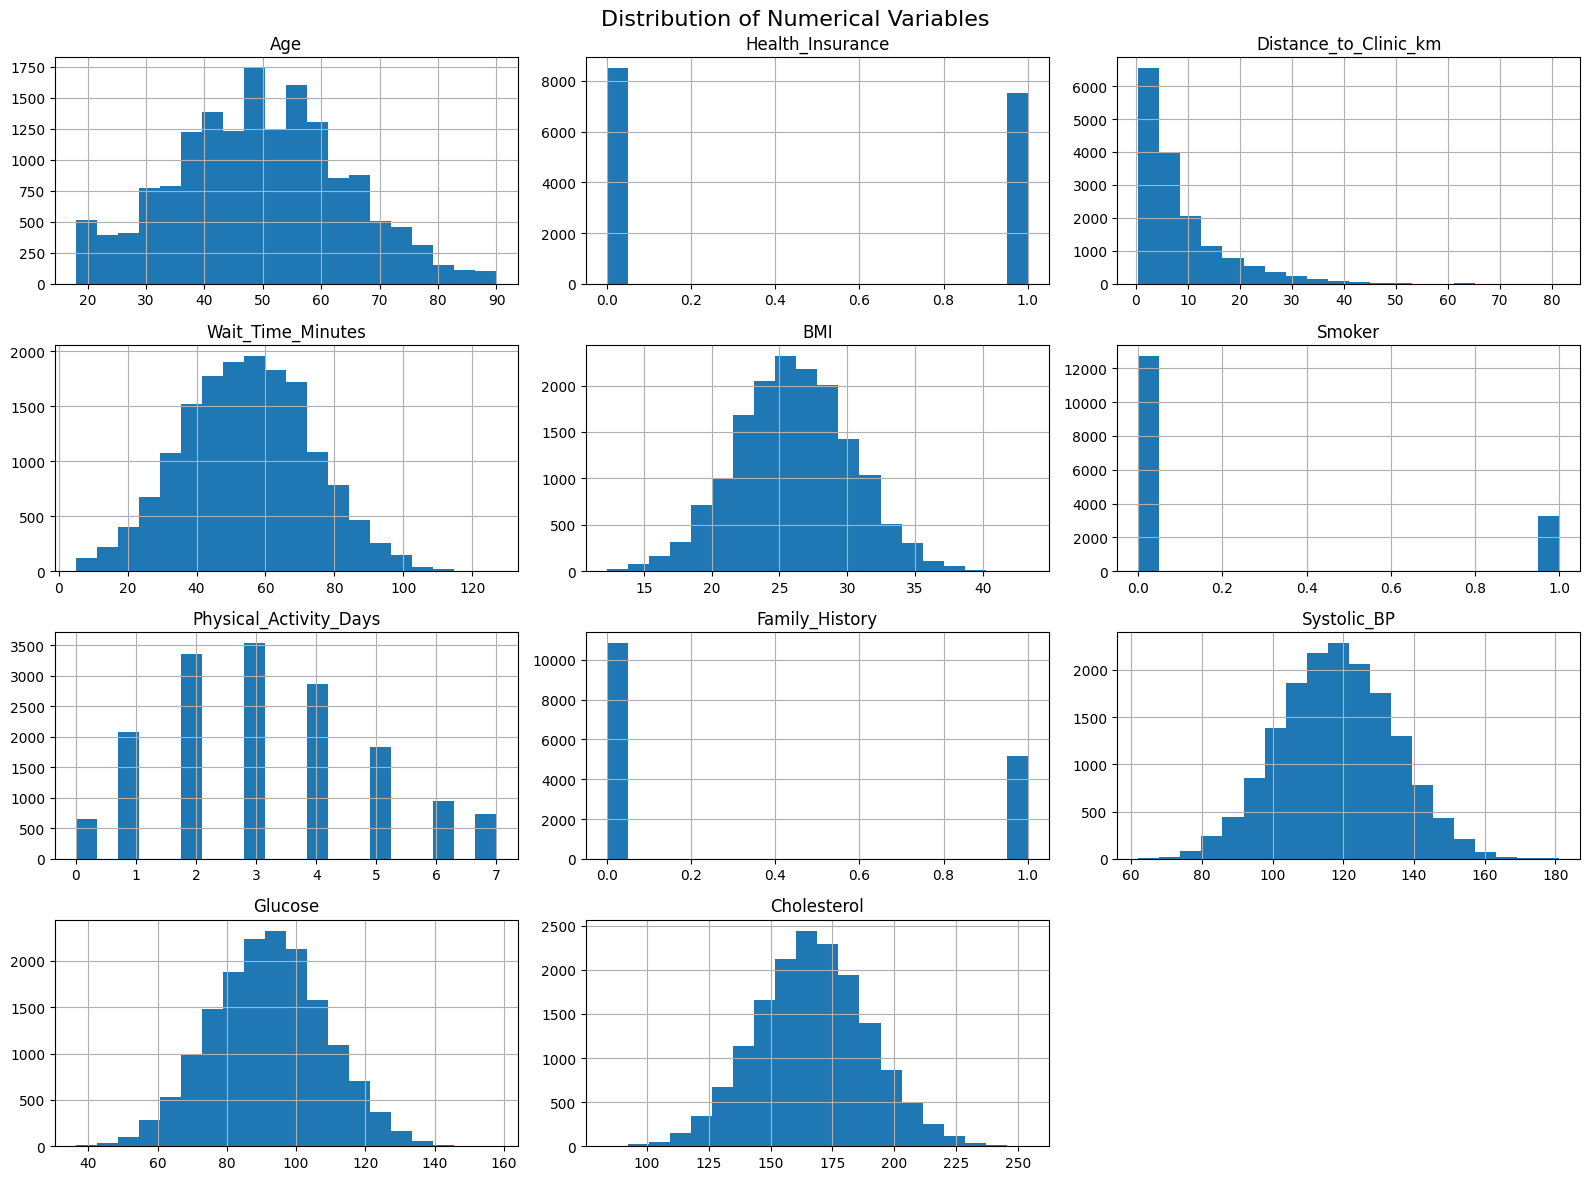

In [15]:
# ------------------------------------------------------------
# Histograms for numerical variables
# ------------------------------------------------------------
numeric_columns = df.select_dtypes(
    include=np.number
).columns.drop(
    ["Outcome"],
    errors="ignore"
)

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

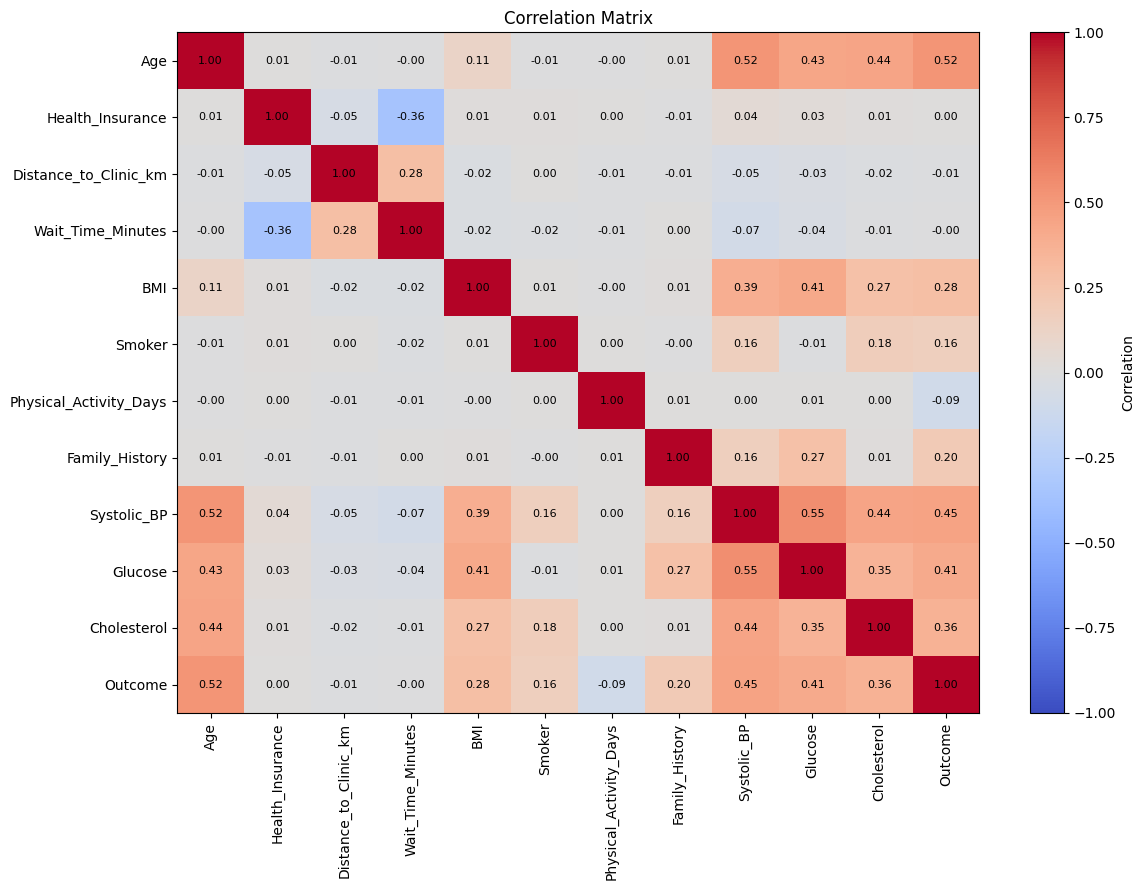

EDA completed successfully.


In [16]:
# ------------------------------------------------------------
# Correlation Matrix with Cell Labels
# ------------------------------------------------------------

correlation_matrix = (
    df.select_dtypes(include=np.number)
    .corr()
)

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

# Add correlation values inside each cell
for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):

        correlation_value = correlation_matrix.iloc[row, column]

        plt.text(
            column,
            row,
            f"{correlation_value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("EDA completed successfully.")

## 3. Prepare the data

`Sex` is kept for fairness auditing but excluded from the model inputs. This separates **prediction** from **fairness evaluation**.


In [17]:
# ============================================================
# Define Features, Target and Protected Attribute
# ============================================================

target_column = "Outcome"
protected_attribute = "Sex"

# Exclude the target, protected attribute and identifier
X = df.drop(
    columns=[
        target_column,
        protected_attribute,
        "Patient_ID"
    ]
)

y = df[target_column]

# Retain the protected attribute separately
sensitive_features = df[protected_attribute]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nPredictor variables:")
print(X.columns.tolist())

print("\nProtected attribute:", protected_attribute)

Feature matrix shape: (16000, 13)
Target shape: (16000,)

Predictor variables:
['Age', 'Residence', 'Income_Group', 'Health_Insurance', 'Distance_to_Clinic_km', 'Wait_Time_Minutes', 'BMI', 'Smoker', 'Physical_Activity_Days', 'Family_History', 'Systolic_BP', 'Glucose', 'Cholesterol']

Protected attribute: Sex


### Train/test split

An 80/20 split is used with a fixed random seed for reproducibility.


In [18]:
# ============================================================
# Reproducible Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Align the protected attribute with retained row indices
sensitive_train = sensitive_features.loc[X_train.index]
sensitive_test = sensitive_features.loc[X_test.index]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining outcome distribution:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .rename("Proportion")
    .to_frame()
)

print("\nTesting outcome distribution:")
display(
    y_test.value_counts(normalize=True)
    .sort_index()
    .rename("Proportion")
    .to_frame()
)

print("\nProtected groups in training data:")
print(sensitive_train.value_counts())

print("\nProtected groups in testing data:")
print(sensitive_test.value_counts())

Training samples: 12800
Testing samples: 3200

Training outcome distribution:


,Proportion
Outcome,
0,0.584844
1,0.415156



Testing outcome distribution:


,Proportion
Outcome,
0,0.585
1,0.415



Protected groups in training data:
Sex
Female    6631
Male      6169
Name: count, dtype: int64

Protected groups in testing data:
Sex
Female    1695
Male      1505
Name: count, dtype: int64


## 4. Baseline model

A Logistic Regression pipeline provides a transparent reference model before any fairness intervention.


In [19]:
# ============================================================
# Baseline Logistic Regression Pipeline
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_probabilities = baseline_model.predict_proba(
    X_test
)[:, 1]

print("Baseline Logistic Regression trained successfully.")

print("\nPredicted class distribution:")
print(
    pd.Series(
        baseline_predictions
    ).value_counts()
)

Numerical features:
['Age', 'Health_Insurance', 'Distance_to_Clinic_km', 'Wait_Time_Minutes', 'BMI', 'Smoker', 'Physical_Activity_Days', 'Family_History', 'Systolic_BP', 'Glucose', 'Cholesterol']

Categorical features:
['Residence', 'Income_Group']
Baseline Logistic Regression trained successfully.

Predicted class distribution:
0    1952
1    1248
Name: count, dtype: int64


## 5. Predictive performance

The baseline reaches **84.8% accuracy** and **0.81 F1-score**. Performance is strong overall, but aggregate metrics alone do not tell us whether errors are distributed fairly.


BASELINE LOGISTIC REGRESSION PERFORMANCE


,Metric,Score
0,Accuracy,0.8475
1,Precision,0.8365
2,Recall,0.7861
3,F1-score,0.8106



Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1872
           1       0.84      0.79      0.81      1328

    accuracy                           0.85      3200
   macro avg       0.85      0.84      0.84      3200
weighted avg       0.85      0.85      0.85      3200



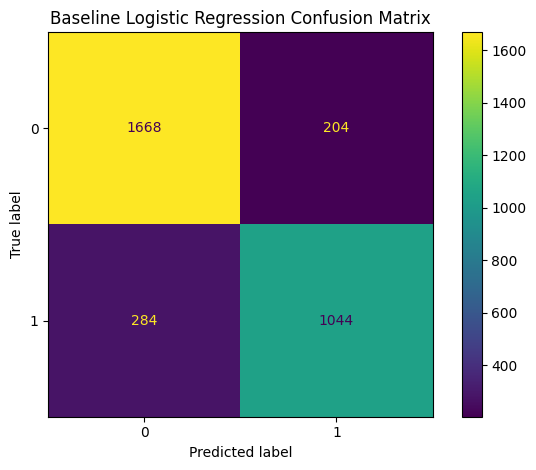

In [20]:
# ============================================================
# Baseline Predictive Performance
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

print("=" * 60)
print("BASELINE LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

display(
    baseline_performance.round(4)
)

print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        baseline_predictions,
        zero_division=0
    )
)

# Confusion matrix
confusion = confusion_matrix(
    y_test,
    baseline_predictions
)

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=baseline_model.classes_
)

display_confusion.plot()

plt.title(
    "Baseline Logistic Regression Confusion Matrix"
)

plt.grid(False)
plt.tight_layout()
plt.show()

## 6. Baseline fairness

I measure:

- **Demographic Parity Difference (DPD):** gap in positive prediction rates.
- **Equalized Odds Difference (EOD):** gap in error-related rates.

For both, values closer to **0** indicate smaller measured disparities.


In [21]:
# ============================================================
# Baseline Fairness Metrics
# ============================================================

baseline_dpd = demographic_parity_difference(
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=sensitive_test
)

baseline_eod = equalized_odds_difference(
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=sensitive_test
)

print("=" * 60)
print("BASELINE FAIRNESS ANALYSIS")
print("=" * 60)

print(
    "Demographic Parity Difference:",
    round(baseline_dpd, 4)
)

print(
    "Equalized Odds Difference:",
    round(baseline_eod, 4)
)

print(
    "\nValues closer to zero indicate "
    "smaller measured disparities."
)

BASELINE FAIRNESS ANALYSIS
Demographic Parity Difference: 0.1531
Equalized Odds Difference: 0.1666

Values closer to zero indicate smaller measured disparities.


### Where does the disparity come from?

Overall accuracy is similar across groups, but the model behaves differently:

- Female TPR: **0.706**
- Male TPR: **0.873**
- Female FPR: **0.051**
- Male FPR: **0.176**

The main issue is therefore not overall accuracy, but **who receives positive predictions and who experiences errors**.


In [22]:
# ============================================================
# Group-Specific Fairness Analysis
# ============================================================

group_metric_frame = MetricFrame(
    metrics={
        "Accuracy": accuracy_score,
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate,
        "False Positive Rate": false_positive_rate
    },
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=sensitive_test
)

print("Overall metrics:")
display(
    pd.DataFrame(
        group_metric_frame.overall,
        columns=["Overall"]
    )
)

print("\nMetrics by protected group:")
display(
    group_metric_frame.by_group.round(4)
)

Overall metrics:


,Overall
Accuracy,0.847500
Selection Rate,0.390000
True Positive Rate,0.786145
False Positive Rate,0.108974



Metrics by protected group:


,Accuracy,Selection Rate,True Positive Rate,False Positive Rate
Sex,,,,
Female,0.8501,0.3180,0.7062,0.0508
Male,0.8445,0.4711,0.8728,0.1763


## 7. Visualizing the fairness gap

The first plots summarize DPD and EOD before mitigation.


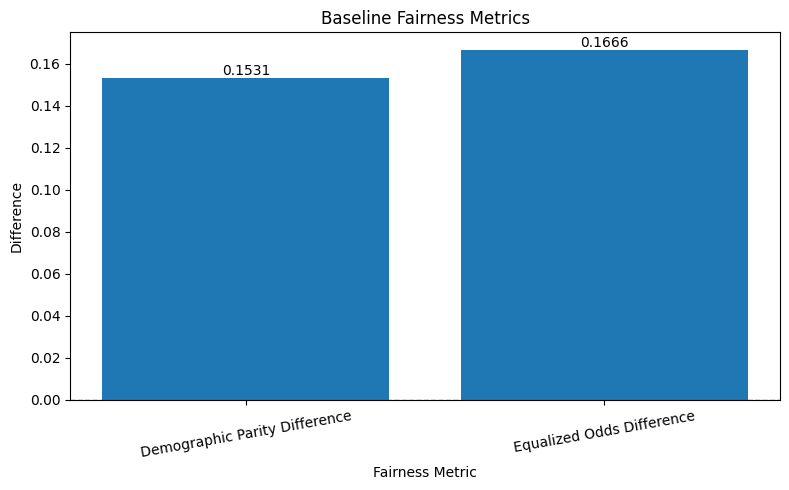

In [23]:
# ============================================================
# Baseline Fairness Visualizations
# ============================================================

baseline_fairness_values = pd.Series({
    "Demographic Parity Difference": baseline_dpd,
    "Equalized Odds Difference": baseline_eod
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    baseline_fairness_values.index,
    baseline_fairness_values.values
)

plt.title("Baseline Fairness Metrics")
plt.ylabel("Difference")
plt.xlabel("Fairness Metric")
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=10)

for bar, value in zip(
    bars,
    baseline_fairness_values.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Group-specific behavior

Selection rate, true-positive rate, and false-positive rate reveal where the aggregate fairness gap originates.


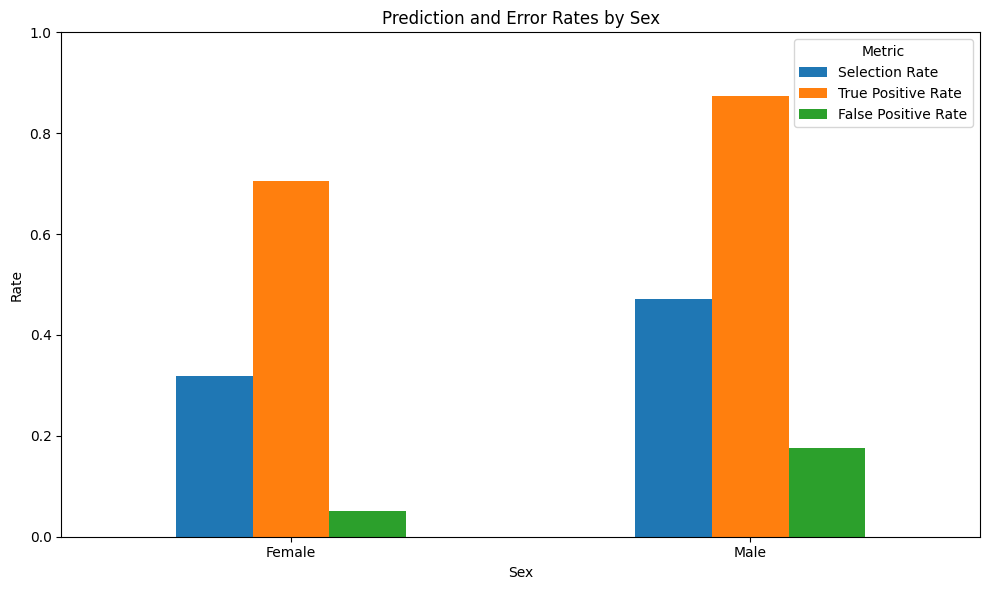

In [24]:
# ============================================================
# Group-Specific Rate Visualizations
# ============================================================

group_rates = (
    group_metric_frame.by_group[
        [
            "Selection Rate",
            "True Positive Rate",
            "False Positive Rate"
        ]
    ]
)

group_rates.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Prediction and Error Rates by Sex")
plt.xlabel("Sex")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 8. Fairlearn post-processing

I apply `ThresholdOptimizer` with an **Equalized Odds** constraint.

This does not retrain the classifier. Instead, it adjusts decision thresholds by group to reduce disparities in TPR and FPR.


In [25]:
# ============================================================
# Fairlearn Threshold Optimization
# ============================================================

threshold_optimizer = ThresholdOptimizer(
    estimator=baseline_model,
    constraints="equalized_odds",
    objective="accuracy_score",
    predict_method="predict_proba",
    prefit=True
)

# Learn group-specific threshold rules using the training data
threshold_optimizer.fit(
    X_train,
    y_train,
    sensitive_features=sensitive_train
)

# Generate mitigated predictions
mitigated_predictions = threshold_optimizer.predict(
    X_test,
    sensitive_features=sensitive_test,
    random_state=42
)

print("Fairlearn mitigation completed.")

print("\nBaseline prediction distribution:")
print(
    pd.Series(
        baseline_predictions
    ).value_counts()
)

print("\nMitigated prediction distribution:")
print(
    pd.Series(
        mitigated_predictions
    ).value_counts()
)

number_changed = np.sum(
    baseline_predictions
    != mitigated_predictions
)

print(
    "\nNumber of predictions changed:",
    number_changed
)

Fairlearn mitigation completed.

Baseline prediction distribution:
0    1952
1    1248
Name: count, dtype: int64

Mitigated prediction distribution:
0    1998
1    1202
Name: count, dtype: int64

Number of predictions changed: 204


## 9. Before vs after mitigation

The post-processing step changes only **204 of 3,200 test predictions**, yet the fairness metrics improve sharply:

- DPD: **0.153 → 0.023**
- EOD: **0.167 → 0.016**

Accuracy also increases from **0.848 to 0.863** in this split.


In [26]:
# ============================================================
# Before-and-After Evaluation
# ============================================================

mitigated_accuracy = accuracy_score(
    y_test,
    mitigated_predictions
)

mitigated_precision = precision_score(
    y_test,
    mitigated_predictions,
    zero_division=0
)

mitigated_recall = recall_score(
    y_test,
    mitigated_predictions,
    zero_division=0
)

mitigated_f1 = f1_score(
    y_test,
    mitigated_predictions,
    zero_division=0
)

mitigated_dpd = demographic_parity_difference(
    y_true=y_test,
    y_pred=mitigated_predictions,
    sensitive_features=sensitive_test
)

mitigated_eod = equalized_odds_difference(
    y_true=y_test,
    y_pred=mitigated_predictions,
    sensitive_features=sensitive_test
)

comparison_results = pd.DataFrame({
    "Before Mitigation": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_dpd,
        baseline_eod
    ],
    "After Mitigation": [
        mitigated_accuracy,
        mitigated_precision,
        mitigated_recall,
        mitigated_f1,
        mitigated_dpd,
        mitigated_eod
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "DPD",
    "EOD"
])

print("=" * 70)
print("BEFORE-AND-AFTER MITIGATION COMPARISON")
print("=" * 70)

display(
    comparison_results.round(4)
)

print("\nFairness changes:")

print(
    f"DPD: {baseline_dpd:.4f} "
    f"→ {mitigated_dpd:.4f}"
)

print(
    f"EOD: {baseline_eod:.4f} "
    f"→ {mitigated_eod:.4f}"
)

BEFORE-AND-AFTER MITIGATION COMPARISON


,Before Mitigation,After Mitigation
Accuracy,0.8475,0.8625
Precision,0.8365,0.8694
Recall,0.7861,0.7869
F1-score,0.8106,0.8261
DPD,0.1531,0.0234
EOD,0.1666,0.0155



Fairness changes:
DPD: 0.1531 → 0.0234
EOD: 0.1666 → 0.0155


### Predictive performance after mitigation

Here I compare accuracy, precision, recall, and F1-score before and after threshold optimization.


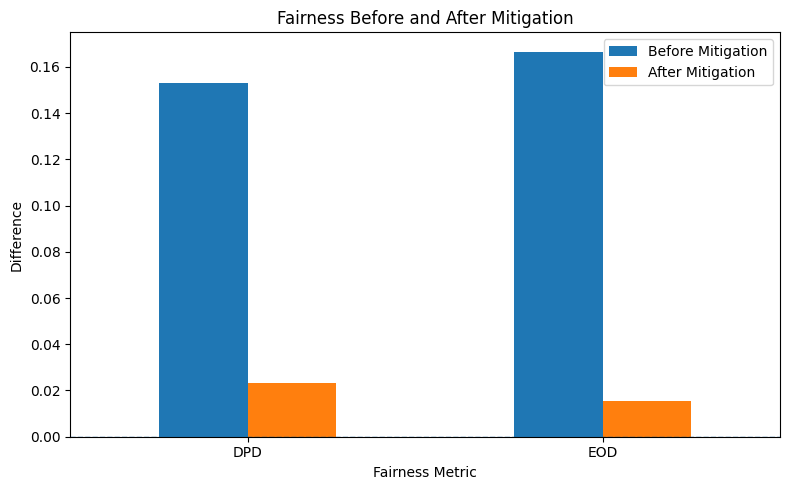

In [27]:
# ============================================================
# Fairness Comparison Visualization
# ============================================================

fairness_comparison = comparison_results.loc[
    [
        "DPD",
        "EOD"
    ]
]

fairness_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Fairness Before and After Mitigation"
)

plt.xlabel("Fairness Metric")
plt.ylabel("Difference")
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

### What changed across groups?

After mitigation, group-specific rates become much closer:

- TPR: **0.783 vs 0.791**
- FPR: **0.077 vs 0.092**
- Selection rate: **0.365 vs 0.388**

This is the clearest evidence that the intervention reduced measured disparity.


In [28]:
# ============================================================
# Group-Specific Comparison
# ============================================================

before_group_metrics = MetricFrame(
    metrics={
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate,
        "False Positive Rate": false_positive_rate
    },
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=sensitive_test
)

after_group_metrics = MetricFrame(
    metrics={
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate,
        "False Positive Rate": false_positive_rate
    },
    y_true=y_test,
    y_pred=mitigated_predictions,
    sensitive_features=sensitive_test
)

print("Before mitigation:")
display(
    before_group_metrics.by_group.round(4)
)

print("\nAfter mitigation:")
display(
    after_group_metrics.by_group.round(4)
)

Before mitigation:


,Selection Rate,True Positive Rate,False Positive Rate
Sex,,,
Female,0.3180,0.7062,0.0508
Male,0.4711,0.8728,0.1763



After mitigation:


,Selection Rate,True Positive Rate,False Positive Rate
Sex,,,
Female,0.3646,0.7829,0.0767
Male,0.3880,0.7912,0.0922


## 10. Fairness-aware neural network

The second strategy addresses fairness **during training**.

The loss becomes:

\[
L = L_{classification} + \lambda L_{fairness}
\]

where the fairness penalty reduces the gap in mean predicted positive probability between groups.


In [29]:
# ============================================================
# Prepare Data for PyTorch
# ============================================================

# Fit the preprocessor using training data only
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

# Convert sparse matrices to dense arrays when necessary
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

# Reset indices so arrays align correctly
y_train_array = (
    y_train
    .reset_index(drop=True)
    .to_numpy()
)

y_test_array = (
    y_test
    .reset_index(drop=True)
    .to_numpy()
)

sensitive_train_reset = (
    sensitive_train
    .reset_index(drop=True)
)

sensitive_test_reset = (
    sensitive_test
    .reset_index(drop=True)
)

# Encode Female = 0 and Male = 1
sensitive_mapping = {
    "Female": 0,
    "Male": 1
}

sensitive_train_encoded = (
    sensitive_train_reset
    .map(sensitive_mapping)
    .to_numpy()
)

sensitive_test_encoded = (
    sensitive_test_reset
    .map(sensitive_mapping)
    .to_numpy()
)

# Convert arrays to tensors
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_array,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test_array,
    dtype=torch.float32
).view(-1, 1)

sensitive_train_tensor = torch.tensor(
    sensitive_train_encoded,
    dtype=torch.long
)

print(
    "PyTorch training tensor shape:",
    X_train_tensor.shape
)

print(
    "PyTorch testing tensor shape:",
    X_test_tensor.shape
)

PyTorch training tensor shape: torch.Size([12800, 14])
PyTorch testing tensor shape: torch.Size([3200, 14])


### Model and fairness penalty

A small PyTorch network is trained with and without the fairness term.


In [30]:
# ============================================================
# Define Fairness-Aware Neural Network
# ============================================================

class FairnessAwareNetwork(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


def demographic_parity_penalty(
    predicted_probabilities,
    sensitive_attribute
):
    """
    Penalizes differences in the average predicted positive
    probability across protected groups.
    """

    group_zero_mask = sensitive_attribute == 0
    group_one_mask = sensitive_attribute == 1

    group_zero_mean = predicted_probabilities[
        group_zero_mask
    ].mean()

    group_one_mean = predicted_probabilities[
        group_one_mask
    ].mean()

    return torch.abs(
        group_zero_mean - group_one_mean
    )

### Train both neural networks

The same architecture is used so the main difference is the fairness-aware objective.


In [31]:
# ============================================================
# Train PyTorch Models
# ============================================================

def train_pytorch_model(
    fairness_weight=0.0,
    epochs=300,
    learning_rate=0.001
):
    # Reset seed before each model
    torch.manual_seed(42)

    model = FairnessAwareNetwork(
        input_size=X_train_tensor.shape[1]
    )

    classification_loss_function = (
        nn.BCEWithLogitsLoss()
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    training_history = {
        "classification_loss": [],
        "fairness_penalty": [],
        "total_loss": []
    }

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        logits = model(
            X_train_tensor
        )

        predicted_probabilities = torch.sigmoid(
            logits
        )

        classification_loss = (
            classification_loss_function(
                logits,
                y_train_tensor
            )
        )

        fairness_penalty = (
            demographic_parity_penalty(
                predicted_probabilities,
                sensitive_train_tensor
            )
        )

        total_loss = (
            classification_loss
            + fairness_weight
            * fairness_penalty
        )

        total_loss.backward()
        optimizer.step()

        training_history[
            "classification_loss"
        ].append(
            classification_loss.item()
        )

        training_history[
            "fairness_penalty"
        ].append(
            fairness_penalty.item()
        )

        training_history[
            "total_loss"
        ].append(
            total_loss.item()
        )

    return model, training_history


# Standard neural network
standard_nn, standard_history = train_pytorch_model(
    fairness_weight=0.0
)

# Fairness-aware neural network
fairness_lambda = 2.0

fair_nn, fair_history = train_pytorch_model(
    fairness_weight=fairness_lambda
)

print("PyTorch models trained successfully.")

PyTorch models trained successfully.


### Generate predictions

Predictions from the standard and fairness-aware networks are compared on the same test set.


In [32]:
# ============================================================
# Generate PyTorch Predictions
# ============================================================

def generate_pytorch_predictions(
    model,
    X_tensor,
    threshold=0.50
):
    model.eval()

    with torch.no_grad():

        logits = model(
            X_tensor
        )

        probabilities = torch.sigmoid(
            logits
        ).numpy().flatten()

    predictions = (
        probabilities >= threshold
    ).astype(int)

    return predictions, probabilities


standard_nn_predictions, standard_nn_probabilities = (
    generate_pytorch_predictions(
        standard_nn,
        X_test_tensor
    )
)

fair_nn_predictions, fair_nn_probabilities = (
    generate_pytorch_predictions(
        fair_nn,
        X_test_tensor
    )
)

print("Standard neural network predictions:")
print(
    pd.Series(
        standard_nn_predictions
    ).value_counts()
)

print("\nFairness-aware neural network predictions:")
print(
    pd.Series(
        fair_nn_predictions
    ).value_counts()
)

Standard neural network predictions:
0    1958
1    1242
Name: count, dtype: int64

Fairness-aware neural network predictions:
0    1968
1    1232
Name: count, dtype: int64


### Fairness–performance trade-off

The fairness-aware network substantially reduces disparity:

- DPD: **0.157 → 0.002**
- EOD: **0.171 → 0.019**

But accuracy falls from **0.848 to 0.822** and recall from **0.784 to 0.749**.

Unlike ThresholdOptimizer, this approach achieves fairness at a visible predictive cost.


In [33]:
# ============================================================
# Evaluate PyTorch Models
# ============================================================

def evaluate_predictions(
    y_true,
    predictions,
    sensitive_attribute
):
    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "DPD": demographic_parity_difference(
            y_true=y_true,
            y_pred=predictions,
            sensitive_features=sensitive_attribute
        ),
        "EOD": equalized_odds_difference(
            y_true=y_true,
            y_pred=predictions,
            sensitive_features=sensitive_attribute
        )
    }


standard_nn_results = evaluate_predictions(
    y_test_array,
    standard_nn_predictions,
    sensitive_test_reset
)

fair_nn_results = evaluate_predictions(
    y_test_array,
    fair_nn_predictions,
    sensitive_test_reset
)

pytorch_comparison = pd.DataFrame({
    "Standard Neural Network":
        standard_nn_results,
    "Fairness-Aware Neural Network":
        fair_nn_results
})

print("=" * 70)
print("PYTORCH MODEL COMPARISON")
print("=" * 70)

display(
    pytorch_comparison.round(4)
)

PYTORCH MODEL COMPARISON


,Standard Neural Network,Fairness-Aware Neural Network
Accuracy,0.8475,0.8219
Precision,0.8382,0.8076
Recall,0.7839,0.7492
F1-score,0.8101,0.7773
DPD,0.1566,0.0018
EOD,0.1710,0.0189


### Fairness comparison

The plots show how strongly the fairness penalty compresses DPD and EOD.


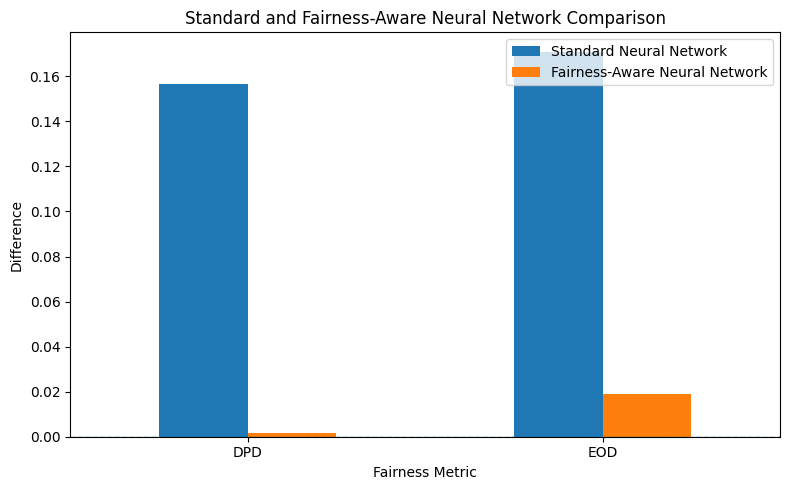

In [34]:
# ============================================================
# PyTorch Fairness Visualization
# ============================================================

pytorch_comparison.loc[
    [
        "DPD",
        "EOD"
    ]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Standard and Fairness-Aware "
    "Neural Network Comparison"
)

plt.xlabel("Fairness Metric")
plt.ylabel("Difference")
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

### Training dynamics

The loss curves help verify whether both networks trained stably.


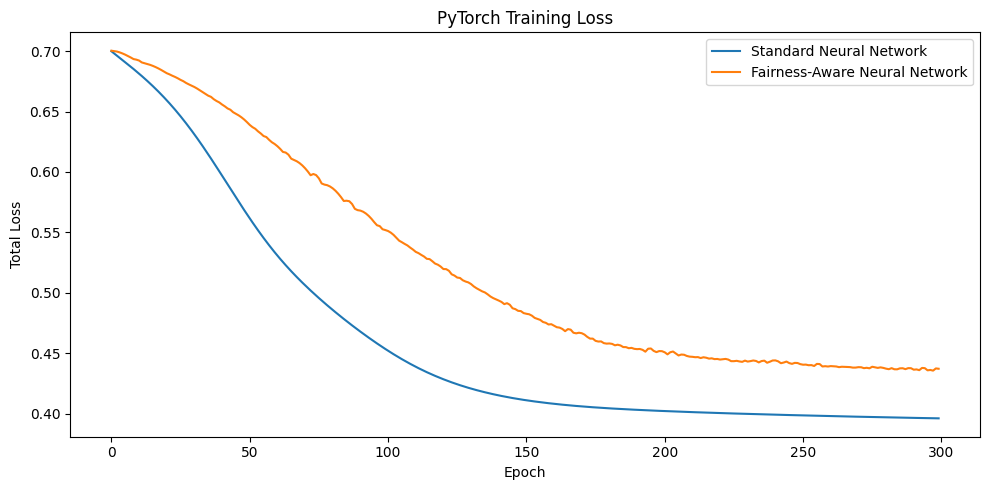

In [35]:
# ============================================================
# PyTorch Training Loss Visualization
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    standard_history["total_loss"],
    label="Standard Neural Network"
)

plt.plot(
    fair_history["total_loss"],
    label="Fairness-Aware Neural Network"
)

plt.title("PyTorch Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.legend()
plt.tight_layout()
plt.show()

## When demographic labels are unavailable

Without protected-group labels, metrics such as DPD and EOD cannot be computed directly. **Not measuring disparity is not evidence of fairness.**

Useful alternatives include subgroup error analysis, geographic or language slices, clustering, worst-group evaluation, and counterfactual tests. These can reveal weaknesses, but they should not be treated as substitutes for real demographic auditing.

When possible, demographic data should be collected transparently, with clear purpose, privacy safeguards, and stakeholder involvement.

## Final takeaway

This notebook shows two very different mitigation paths:

- **ThresholdOptimizer:** large fairness gains with no performance loss in this experiment.
- **Fairness-aware neural network:** even stronger parity, but lower accuracy and recall.

The main lesson is simple: **fairness should be evaluated alongside performance, not after it.**


In [36]:
# ============================================================
# Final Tutorial Summary
# ============================================================

print("=" * 70)
print("FINAL TUTORIAL SUMMARY")
print("=" * 70)

print("\nBaseline Logistic Regression")
print(
    comparison_results[
        ["Before Mitigation"]
    ].round(4)
)

print("\nFairlearn-Mitigated Logistic Regression")
print(
    comparison_results[
        ["After Mitigation"]
    ].round(4)
)

print("\nPyTorch Comparison")
print(
    pytorch_comparison.round(4)
)

print("\nKey interpretation:")
print(
    "- DPD and EOD values closer to zero "
    "indicate smaller measured disparities."
)

print(
    "- Fairness mitigation may improve "
    "fairness while changing predictive performance."
)

print(
    "- The fairness-aware PyTorch loss illustrates "
    "how fairness can be incorporated during training."
)

print(
    "- Different fairness definitions may produce "
    "different trade-offs."
)

FINAL TUTORIAL SUMMARY

Baseline Logistic Regression
           Before Mitigation
Accuracy              0.8475
Precision             0.8365
Recall                0.7861
F1-score              0.8106
DPD                   0.1531
EOD                   0.1666

Fairlearn-Mitigated Logistic Regression
           After Mitigation
Accuracy             0.8625
Precision            0.8694
Recall               0.7869
F1-score             0.8261
DPD                  0.0234
EOD                  0.0155

PyTorch Comparison
           Standard Neural Network  Fairness-Aware Neural Network
Accuracy                    0.8475                         0.8219
Precision                   0.8382                         0.8076
Recall                      0.7839                         0.7492
F1-score                    0.8101                         0.7773
DPD                         0.1566                         0.0018
EOD                         0.1710                         0.0189

Key interpretation:
- DP